## 📋 Overview
# This notebook demonstrates how LLM-powered translation enhances ML phishing detection
# for non-English emails by providing:
# 1. Contextually accurate translations that preserve phishing indicators
# 2. URL preservation (never translating suspicious links)
# 3. Better handling of informal/slang language than traditional translation APIs

In [1]:
import os
import re
import joblib
import pandas as pd
import numpy as np
import time
from tqdm import tqdm
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from langdetect import detect, LangDetectException
from dotenv import load_dotenv
from typing import Tuple
from openai import OpenAI as OR_OpenAI
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
try:
    CURRENT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    CURRENT_DIR = os.getcwd()

PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))

# Load .env for OpenRouter key
env_path = os.path.join(PROJECT_ROOT, ".env")
if os.path.exists(env_path):
    load_dotenv(env_path)

OPENROUTER_KEY = os.getenv("OPENROUTER_API_KEY")

if not OPENROUTER_KEY:
    print("⚠️ OPENROUTER_API_KEY missing — LLM translation will fail.")
    openrouter_client = None
else:
    openrouter_client = OR_OpenAI(
        api_key=OPENROUTER_KEY,
        base_url="https://openrouter.ai/api/v1"
    )
    print("✅ OpenRouter client configured.")

✅ OpenRouter client configured.


In [3]:
MODEL_IDS = {
    "DeepSeek": "deepseek/deepseek-chat-v3.1",
    "GPT": "openai/gpt-4.1",
    "Claude": "anthropic/claude-3.5-sonnet",
}

In [4]:
URL_REGEX = re.compile(r"https?://[^\s<>\"'\n]+")

def replace_urls_with_placeholders(text: str):
    urls = URL_REGEX.findall(text)
    placeholder_map = {}
    out = text

    for idx, url in enumerate(urls):
        ph = f"[URL_{idx}]"
        placeholder_map[ph] = url
        out = out.replace(url, ph)

    return out, placeholder_map


def restore_placeholders(text: str, placeholder_map: dict):
    for ph, url in placeholder_map.items():
        text = text.replace(ph, url)
    return text


def call_openrouter_model(prompt: str, model_id: str):
    if openrouter_client is None:
        return "❌ LLM not configured.", "error"
    try:
        resp = openrouter_client.chat.completions.create(
            model=model_id,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.2,
            max_tokens=800,
        )
        return resp.choices[0].message.content.strip(), "ok"
    except Exception as e:
        return f"❌ OpenRouter error: {e}", "error"


def detect_and_translate(text: str, model_name: str):
    if not text or not text.strip():
        return text, "unknown", "noop"
    
    # Language detection
    try:
        detected = detect(text)
    except LangDetectException:
        detected = "unknown"
    
    # If English → no translation needed
    if detected in ("en", "unknown"):
        return text, detected, "noop"
    
    # Preserve URLs
    ph_text, ph_map = replace_urls_with_placeholders(text)
    
    # IMPROVED PROMPT - emphasizes preserving phishing signals
    prompt = f"""You are a cybersecurity translation specialist. Translate this email to English while STRICTLY preserving:

1. ALL urgency language (e.g., "urgent", "immediately", "verify now")
2. ALL suspicious phrasing (e.g., "confirm your credentials", "account suspended")
3. ALL placeholders like [URL_0] - DO NOT translate or remove them
4. The EXACT tone and formality level
5. ANY typos or grammatical errors (these are phishing indicators)

DO NOT:
- Summarize or paraphrase
- Fix grammar/spelling
- Make the text more formal or polite
- Remove any details

Translate word-for-word when possible, preserving the suspicious nature of the original text.

--- BEGIN TEXT ---
{ph_text}
--- END TEXT ---

Translation:"""
    
    model_id = MODEL_IDS[model_name]
    translated, status = call_openrouter_model(prompt, model_id)
    if status != "ok":
        return text, detected, "error"
    
    translated = restore_placeholders(translated, ph_map)
    return translated, detected, "ok"

In [5]:
ML_DIR = Path(PROJECT_ROOT) / "ML pipeline"

MODEL_PATH = ML_DIR / "model.pkl"
VECT_PATH = ML_DIR / "tfidf_vectorizer.pkl"

ml_model = joblib.load(MODEL_PATH)
tfidf_vectorizer = joblib.load(VECT_PATH)

print("Loaded:", type(ml_model).__name__, "/", type(tfidf_vectorizer).__name__)

Loaded: CalibratedClassifierCV / TfidfVectorizer


In [6]:
test_emails = [
    # Hungarian - WITH URL
    {"body":"Szia! A céges VPN-hez újra be kell jelentkezned itt: https://company-vpn-login-hu.com/auth?session=x7m2", "label":1},
    # Hungarian - NO URL
    {"body":"Sziasztok! A heti riportot csatoltam az emailhez. Kérem nézzétek át holnap reggelig.", "label":0},
    
    # Spanish - WITH URL
    {"body":"Urgente tío! Tu cuenta PayPal ha sido suspendida. Verifica YA: https://paypal-seguridad-verificacion.es/verify?id=ES8291", "label":1},
    # Spanish - NO URL
    {"body":"Hola! Tu pedido de Amazon llegará mañana entre las 10 y 14 horas. Gracias por tu compra.", "label":0},
    
    # French - WITH URL
    {"body":"Madame, Monsieur, suite à une activité suspecte, veuillez confirmer vos coordonnées bancaires: https://impots-remboursement-gouv.fr/validation?ref=FR2024", "label":1},
    # French - NO URL
    {"body":"Votre réservation à l'hôtel Le Meurice est confirmée pour le 15 mars. Merci de votre confiance.", "label":0},
    
    # German - WITH URL
    {"body":"Achtung! Ihr DHL-Paket wird zurückgeschickt. Zollgebühren bezahlen: https://dhl-paketzustellung-de.com/zoll?track=DE478926", "label":1},
    # German - NO URL
    {"body":"Ihr Meeting wurde auf Donnerstag 14 Uhr verschoben. Bitte bestätigen Sie Ihre Teilnahme per Reply.", "label":0},
    
    # Italian - WITH URL
    {"body":"Gentile cliente Poste Italiane, confermi la sua identità per evitare la sospensione: https://poste-sicurezza-verifica.it/conferma?id=IT8293", "label":1},
    # Italian - NO URL
    {"body":"La sua prenotazione al ristorante La Pergola è confermata per sabato alle 20:00. A presto!", "label":0},
    
    # Russian - WITH URL
    {"body":"Ваша посылка задержана на таможне. Оплатите пошлину: https://russian-post-customs.ru/pay?id=RU8273", "label":1},
    # Russian - NO URL
    {"body":"Ваш билет на рейс Москва-Санкт-Петербург подтвержден на 25 марта. Посадка за час до вылета.", "label":0},
    
    # Japanese - WITH URL
    {"body":"お客様のアカウントが一時停止されました。こちらで確認してください: https://amazon-jp-security.com/verify?id=JP8293", "label":1},
    # Japanese - NO URL
    {"body":"ご注文の商品は明日午前中に配送予定です。ご不在の場合は宅配ボックスに入れます。", "label":0},
    
    # Portuguese - WITH URL
    {"body":"Parabéns! Você ganhou R$ 50.000 na Mega-Sena! Clique para receber: https://caixa-megasena-premio.br/claim?id=BR7821", "label":1},
    # Portuguese - NO URL
    {"body":"Seu voo da LATAM para São Paulo foi confirmado para terça-feira às 15h30. Bom voo!", "label":0},
    
    # Polish - WITH URL
    {"body":"Twoje konto bankowe zostało zablokowane. Odblokuj natychmiast: https://mbank-bezpieczenstwo-pl.com/odblokuj?id=PL9283", "label":1},
    # Polish - NO URL
    {"body":"Twoja faktura za zakupy w Allegro jest dostępna w koncie użytkownika. Sprawdź szczegóły zamówienia.", "label":0},
    
    # Dutch - WITH URL
    {"body":"U heeft recht op een belastingteruggave van €847. Claim hier: https://belastingdienst-teruggave-nl.com/claim?ref=NL2024", "label":1},
    # Dutch - NO URL
    {"body":"Uw bestelling wordt morgen bezorgd tussen 09:00 en 17:00 uur. Bedankt voor uw aankoop bij Bol.com.", "label":0},
    
    # Swedish - WITH URL
    {"body":"Din Swedbank-konto behöver verifieras. Klicka här omedelbart: https://swedbank-sakerhet-se.com/verifiera?id=SE8293", "label":1},
    # Swedish - NO URL
    {"body":"Din flygbiljett med SAS till Stockholm är bokad för fredag kl 10:15. Incheckning öppnar 24 timmar före.", "label":0},
    
    # Turkish - WITH URL
    {"body":"Tebrikler! iPhone 15 kazandınız! Hemen tıklayın: https://apple-turkiye-hediye.com/kazandin?id=TR8293", "label":1},
    # Turkish - NO URL
    {"body":"Siparişiniz Trendyol'dan yola çıktı. Yarın teslim edilecek. İyi günler dileriz!", "label":0},
    
    # Arabic - WITH URL
    {"body":"تنبيه أمني: تم تعليق حسابك المصرفي. يرجى التحقق: https://alrajhi-bank-security.sa/verify?id=SA8293", "label":1},
    # Arabic - NO URL
    {"body":"تم تأكيد حجزك على رحلة الخطوط السعودية إلى جدة يوم الأحد الساعة 14:00. رحلة سعيدة.", "label":0},
    
    # Korean - WITH URL
    {"body":"고객님의 계정이 정지되었습니다. 즉시 확인하세요: https://naver-account-security.kr/verify?id=KR8293", "label":1},
    # Korean - NO URL
    {"body":"쿠팡에서 주문하신 상품이 내일 오전 배송 예정입니다. 감사합니다.", "label":0},
    
    # Czech - WITH URL
    {"body":"Váš balík nemůže být doručen. Zaplaťte poplatek zde: https://ceska-posta-doruceni.cz/platba?id=CZ8293", "label":1},
    # Czech - NO URL
    {"body":"Vaše rezervace v hotelu je potvrzena na 20. března. Těšíme se na vaši návštěvu.", "label":0},
    
    # Greek - WITH URL
    {"body":"Δικαιούστε επιστροφή φόρου €650. Διεκδικήστε εδώ: https://aade-epistrofi-forou.gr/claim?ref=GR2024", "label":1},
    # Greek - NO URL
    {"body":"Η κράτησή σας στην Aegean Airlines για Αθήνα επιβεβαιώθηκε για Δευτέρα 10:30. Καλό ταξίδι!", "label":0},
    
    # Norwegian - WITH URL
    {"body":"Din pakke holdes tilbake. Betal toll nå: https://posten-norge-toll.no/betaling?id=NO8293", "label":1},
    # Norwegian - NO URL
    {"body":"Din flybillett med Norwegian til Oslo er bekreftet for torsdag kl 16:45. God reise!", "label":0},
    
    # Finnish - WITH URL
    {"body":"Nordea-tilisi vaatii vahvistuksen. Vahvista heti: https://nordea-turvallisuus-fi.com/vahvista?id=FI8293", "label":1},
    # Finnish - NO URL
    {"body":"Tilauksesi Verkkokauppa.comista on lähetetty. Paketti saapuu huomenna klo 10-16 välillä.", "label":0},
]

In [7]:
# Cell 6.5: Create DataFrame from test emails
df = pd.DataFrame(test_emails)
# Freeze raw_body (NEVER touched by translations)
df["raw_body"] = df["body"]
print(f"✅ Created DataFrame with {len(df)} emails")
print(f"   - Phishing (label=1): {sum(df.label == 1)}")
print(f"   - Legitimate (label=0): {sum(df.label == 0)}")
df.head()

✅ Created DataFrame with 36 emails
   - Phishing (label=1): 18
   - Legitimate (label=0): 18


,body,label,raw_body
0,Szia! A céges VPN-hez újra be kell jelentkezne...,1,Szia! A céges VPN-hez újra be kell jelentkezne...
1,Sziasztok! A heti riportot csatoltam az emailh...,0,Sziasztok! A heti riportot csatoltam az emailh...
2,Urgente tío! Tu cuenta PayPal ha sido suspendi...,1,Urgente tío! Tu cuenta PayPal ha sido suspendi...
3,Hola! Tu pedido de Amazon llegará mañana entre...,0,Hola! Tu pedido de Amazon llegará mañana entre...
4,"Madame, Monsieur, suite à une activité suspect...",1,"Madame, Monsieur, suite à une activité suspect..."


In [8]:
# ============================
# Timing storage
# ============================

timing = {
    "ml_only_total": 0.0,
    "ml_only_calls": 0,
    "translation": {prov: 0.0 for prov in MODEL_IDS},
    "translation_calls": {prov: 0 for prov in MODEL_IDS},
    "hybrid_ml": {prov: 0.0 for prov in MODEL_IDS},
    "hybrid_ml_calls": {prov: 0 for prov in MODEL_IDS},
}

In [9]:
# ============================================================
# 1) ML-ONLY BASELINE (NO TRANSLATION)
# ============================================================
baseline_preds = []
baseline_confs = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    body = row["raw_body"]
    start_ml = time.perf_counter()

    feat = tfidf_vectorizer.transform([body])
    pred = ml_model.predict(feat)[0]
    
    if hasattr(ml_model, "predict_proba"):
        conf = float(max(ml_model.predict_proba(feat)[0]))
    else:
        conf = 0.0
    
    elapsed_ml = time.perf_counter() - start_ml
    timing["ml_only_total"] += elapsed_ml
    timing["ml_only_calls"] += 1


    if hasattr(ml_model, "predict_proba"):
        conf = float(max(ml_model.predict_proba(feat)[0]))
    else:
        conf = 0.0

    baseline_preds.append(pred)
    baseline_confs.append(conf)

df["baseline_pred"] = baseline_preds
df["baseline_conf"] = baseline_confs

baseline_results = {
    "Accuracy": accuracy_score(df.label, df.baseline_pred),
    "Precision": precision_score(df.label, df.baseline_pred, zero_division=0),
    "Recall": recall_score(df.label, df.baseline_pred, zero_division=0),
    "F1": f1_score(df.label, df.baseline_pred, zero_division=0),
}

baseline_results

100%|██████████| 36/36 [00:00<00:00, 79.88it/s]


{'Accuracy': 0.5277777777777778,
 'Precision': 0.5142857142857142,
 'Recall': 1.0,
 'F1': 0.6792452830188679}

In [10]:
# ============================================================
# 2) LLM TRANSLATIONS (BODY ONLY)
# ============================================================
for prov in MODEL_IDS:
    print(f"🔵 Translating bodies using {prov} ...")

    translated_list = []
    for raw in tqdm(df["raw_body"], total=len(df)):
        start_llm = time.perf_counter()

        translated, lang, status = detect_and_translate(raw, prov)
        
        elapsed_llm = time.perf_counter() - start_llm
        timing["translation"][prov] += elapsed_llm
        timing["translation_calls"][prov] += 1

        if status != "ok":
            translated_list.append(raw)
        else:
            translated_list.append(translated)

    df[f"llm_{prov}_translation"] = translated_list

df

🔵 Translating bodies using DeepSeek ...


100%|██████████| 36/36 [01:14<00:00,  2.07s/it]


🔵 Translating bodies using GPT ...


100%|██████████| 36/36 [00:49<00:00,  1.37s/it]


🔵 Translating bodies using Claude ...


100%|██████████| 36/36 [02:16<00:00,  3.80s/it]


,body,label,raw_body,baseline_pred,baseline_conf,llm_DeepSeek_translation,llm_GPT_translation,llm_Claude_translation
0,Szia! A céges VPN-hez újra be kell jelentkezne...,1,Szia! A céges VPN-hez újra be kell jelentkezne...,1,0.966259,Hi! You need to log in again to the company VP...,Hi! You have to login again to the company VPN...,"Here is the precise translation, preserving al..."
1,Sziasztok! A heti riportot csatoltam az emailh...,0,Sziasztok! A heti riportot csatoltam az emailh...,1,0.925894,Hi everyone! I have attached the weekly report...,Hi All! I attached the weekly report to the em...,Hi everyone! I attached the weekly report to t...
2,Urgente tío! Tu cuenta PayPal ha sido suspendi...,1,Urgente tío! Tu cuenta PayPal ha sido suspendi...,1,0.996766,Of course. Here is the translation that strict...,Urgent dude! Your PayPal account has been susp...,Here's the precise translation maintaining all...
3,Hola! Tu pedido de Amazon llegará mañana entre...,0,Hola! Tu pedido de Amazon llegará mañana entre...,1,0.945599,Hello! Your Amazon order will arrive tomorrow ...,Hello! Your Amazon order will arrive tomorrow ...,"Here's the precise translation, preserving all..."
4,"Madame, Monsieur, suite à une activité suspect...",1,"Madame, Monsieur, suite à une activité suspect...",1,0.938041,"Madam, Sir, following a suspicious activity, p...","Sir, Madam, following a suspicious activity, p...",Here's the precise translation preserving all ...
5,Votre réservation à l'hôtel Le Meurice est con...,0,Votre réservation à l'hôtel Le Meurice est con...,1,0.983926,Your reservation at the hotel Le Meurice is co...,Your reservation at the hotel Le Meurice is co...,Your reservation at Le Meurice hotel is confir...
6,Achtung! Ihr DHL-Paket wird zurückgeschickt. Z...,1,Achtung! Ihr DHL-Paket wird zurückgeschickt. Z...,1,0.903334,Attention! Your DHL package is being returned....,Attention! Your DHL package will be returned. ...,Here's the precise translation preserving all ...
7,Ihr Meeting wurde auf Donnerstag 14 Uhr versch...,0,Ihr Meeting wurde auf Donnerstag 14 Uhr versch...,1,0.556897,Your Meeting has been postponed to Thursday 2 ...,Your meeting was moved to Thursday 2pm. Please...,Your meeting has been moved to Thursday 2 PM. ...
8,"Gentile cliente Poste Italiane, confermi la su...",1,"Gentile cliente Poste Italiane, confermi la su...",1,0.596479,Of course. As a cybersecurity translation spec...,"Dear Poste Italiane customer, confirm your ide...","Dear Poste Italiane customer, confirm your ide..."
9,La sua prenotazione al ristorante La Pergola è...,0,La sua prenotazione al ristorante La Pergola è...,1,0.942508,Your reservation at restaurant La Pergola is c...,Your reservation at the restaurant La Pergola ...,Your reservation at La Pergola restaurant is c...


In [11]:
# ============================================================
# 3) ML on translated bodies (Hybrid)
# ============================================================
for prov in MODEL_IDS:
    preds = []
    confs = []
    col = f"llm_{prov}_translation"

    print(f"🟣 Running ML on {prov} translations...")

    for txt in df[col]:
        start_ml = time.perf_counter()

        feat = tfidf_vectorizer.transform([txt])
        pred = ml_model.predict(feat)[0]
        
        if hasattr(ml_model, "predict_proba"):
            conf = float(max(ml_model.predict_proba(feat)[0]))
        else:
            conf = 0.0
        
        elapsed_ml = time.perf_counter() - start_ml
        timing["hybrid_ml"][prov] += elapsed_ml
        timing["hybrid_ml_calls"][prov] += 1

        if hasattr(ml_model, "predict_proba"):
            conf = float(max(ml_model.predict_proba(feat)[0]))
        else:
            conf = 0.0

        preds.append(pred)
        confs.append(conf)

    df[f"ml_{prov}_pred"] = preds
    df[f"ml_{prov}_conf"] = confs

df

🟣 Running ML on DeepSeek translations...
🟣 Running ML on GPT translations...
🟣 Running ML on Claude translations...


,body,label,raw_body,baseline_pred,baseline_conf,llm_DeepSeek_translation,llm_GPT_translation,llm_Claude_translation,ml_DeepSeek_pred,ml_DeepSeek_conf,ml_GPT_pred,ml_GPT_conf,ml_Claude_pred,ml_Claude_conf
0,Szia! A céges VPN-hez újra be kell jelentkezne...,1,Szia! A céges VPN-hez újra be kell jelentkezne...,1,0.966259,Hi! You need to log in again to the company VP...,Hi! You have to login again to the company VPN...,"Here is the precise translation, preserving al...",0,0.713520,1,0.810703,0,0.783671
1,Sziasztok! A heti riportot csatoltam az emailh...,0,Sziasztok! A heti riportot csatoltam az emailh...,1,0.925894,Hi everyone! I have attached the weekly report...,Hi All! I attached the weekly report to the em...,Hi everyone! I attached the weekly report to t...,0,0.977132,0,0.911814,0,0.887908
2,Urgente tío! Tu cuenta PayPal ha sido suspendi...,1,Urgente tío! Tu cuenta PayPal ha sido suspendi...,1,0.996766,Of course. Here is the translation that strict...,Urgent dude! Your PayPal account has been susp...,Here's the precise translation maintaining all...,1,0.989187,1,0.999419,1,0.973611
3,Hola! Tu pedido de Amazon llegará mañana entre...,0,Hola! Tu pedido de Amazon llegará mañana entre...,1,0.945599,Hello! Your Amazon order will arrive tomorrow ...,Hello! Your Amazon order will arrive tomorrow ...,"Here's the precise translation, preserving all...",1,0.792146,1,0.792146,1,0.763160
4,"Madame, Monsieur, suite à une activité suspect...",1,"Madame, Monsieur, suite à une activité suspect...",1,0.938041,"Madam, Sir, following a suspicious activity, p...","Sir, Madam, following a suspicious activity, p...",Here's the precise translation preserving all ...,1,0.982692,1,0.988987,1,0.962725
5,Votre réservation à l'hôtel Le Meurice est con...,0,Votre réservation à l'hôtel Le Meurice est con...,1,0.983926,Your reservation at the hotel Le Meurice is co...,Your reservation at the hotel Le Meurice is co...,Your reservation at Le Meurice hotel is confir...,1,0.646155,0,0.508221,0,0.688290
6,Achtung! Ihr DHL-Paket wird zurückgeschickt. Z...,1,Achtung! Ihr DHL-Paket wird zurückgeschickt. Z...,1,0.903334,Attention! Your DHL package is being returned....,Attention! Your DHL package will be returned. ...,Here's the precise translation preserving all ...,1,0.998133,1,0.998133,1,0.980618
7,Ihr Meeting wurde auf Donnerstag 14 Uhr versch...,0,Ihr Meeting wurde auf Donnerstag 14 Uhr versch...,1,0.556897,Your Meeting has been postponed to Thursday 2 ...,Your meeting was moved to Thursday 2pm. Please...,Your meeting has been moved to Thursday 2 PM. ...,0,0.844689,0,0.709408,0,0.907238
8,"Gentile cliente Poste Italiane, confermi la su...",1,"Gentile cliente Poste Italiane, confermi la su...",1,0.596479,Of course. As a cybersecurity translation spec...,"Dear Poste Italiane customer, confirm your ide...","Dear Poste Italiane customer, confirm your ide...",1,0.865458,1,0.979498,1,0.938766
9,La sua prenotazione al ristorante La Pergola è...,0,La sua prenotazione al ristorante La Pergola è...,1,0.942508,Your reservation at restaurant La Pergola is c...,Your reservation at the restaurant La Pergola ...,Your reservation at La Pergola restaurant is c...,1,0.650494,1,0.650494,0,0.664132


In [12]:
rows = []

rows.append({
    "Approach": "ML only (raw body)",
    **baseline_results
})

for prov in MODEL_IDS:
    rows.append({
        "Approach": f"ML + {prov}",
        "Accuracy": accuracy_score(df.label, df[f"ml_{prov}_pred"]),
        "Precision": precision_score(df.label, df[f"ml_{prov}_pred"], zero_division=0),
        "Recall": recall_score(df.label, df[f"ml_{prov}_pred"], zero_division=0),
        "F1": f1_score(df.label, df[f"ml_{prov}_pred"], zero_division=0),
    })

comp_df = pd.DataFrame(rows).set_index("Approach").round(3)
comp_df

,Accuracy,Precision,Recall,F1
Approach,,,,
ML only (raw body),0.528,0.514,1.000,0.679
ML + DeepSeek,0.750,0.680,0.944,0.791
ML + GPT,0.833,0.750,1.000,0.857
ML + Claude,0.806,0.762,0.889,0.821


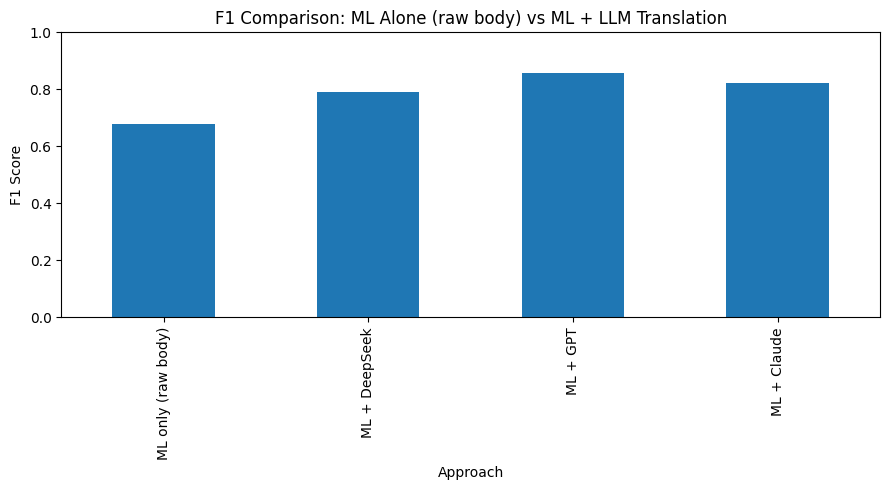

In [13]:
plt.figure(figsize=(9,5))
comp_df["F1"].plot(kind="bar")
plt.title("F1 Comparison: ML Alone (raw body) vs ML + LLM Translation")
plt.ylabel("F1 Score")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

In [14]:
print("\n" + "="*70)
print("⏱️ LATENCY ANALYSIS: ML ONLY vs HYBRID ML + LLM TRANSLATION")
print("="*70)

rows = []

# ML-only
avg_ml_only = timing["ml_only_total"] / timing["ml_only_calls"]
rows.append({
    "Approach": "ML only",
    "Avg ML Time (ms)": avg_ml_only * 1000,
    "Total Time (sec)": timing["ml_only_total"]
})

print(f"\nML ONLY:")
print(f"  Avg inference time: {avg_ml_only*1000:.2f} ms")

# Hybrid
for prov in MODEL_IDS:
    avg_trans = timing["translation"][prov] / timing["translation_calls"][prov]
    avg_hybrid_ml = timing["hybrid_ml"][prov] / timing["hybrid_ml_calls"][prov]
    total_avg = avg_trans + avg_hybrid_ml

    rows.append({
        "Approach": f"ML + {prov}",
        "Avg Translation Time (ms)": avg_trans * 1000,
        "Avg ML Time (ms)": avg_hybrid_ml * 1000,
        "Avg Total Time (ms)": total_avg * 1000
    })

    print(f"\nML + {prov}:")
    print(f"  Avg translation time: {avg_trans*1000:.0f} ms")
    print(f"  Avg ML time:          {avg_hybrid_ml*1000:.2f} ms")
    print(f"  Avg total per email:  {total_avg:.2f} sec")

timing_df = pd.DataFrame(rows).set_index("Approach")
timing_df


⏱️ LATENCY ANALYSIS: ML ONLY vs HYBRID ML + LLM TRANSLATION

ML ONLY:
  Avg inference time: 8.68 ms

ML + DeepSeek:
  Avg translation time: 2071 ms
  Avg ML time:          7.35 ms
  Avg total per email:  2.08 sec

ML + GPT:
  Avg translation time: 1364 ms
  Avg ML time:          6.82 ms
  Avg total per email:  1.37 sec

ML + Claude:
  Avg translation time: 3800 ms
  Avg ML time:          7.68 ms
  Avg total per email:  3.81 sec


,Avg ML Time (ms),Total Time (sec),Avg Translation Time (ms),Avg Total Time (ms)
Approach,,,,
ML only,8.676633,0.312359,NaN,NaN
ML + DeepSeek,7.351981,NaN,2070.711025,2078.063006
ML + GPT,6.823514,NaN,1363.758311,1370.581825
ML + Claude,7.676258,NaN,3800.317114,3807.993372
